In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, mixedlm
import time
from datetime import date

# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath(".."))

In [2]:
### LOAD DATA

In [3]:
# load and combine experimet df

from src.loading import load_data

# -------------------- 3.0 m/s
df_3 = load_data("../data/target_trial_3_2025_11_7.parquet",  keep_col='training_status')
# ------------------- 2.0 m/s
df_2 = load_data("../data/target_trial_2.parquet")
# # drop every row from participant p030 due to corrupted data
df_2 = df_2[df_2['ppid'] != 'p030'].copy()

df_full = pd.concat([df_2, df_3], ignore_index=True)

In [4]:
### FORMAT DF

In [5]:

# add new variables

df_full['lateral_error_x'] = (df_full['min_pos_from_target_x'] - df_full['target_position_x']) 
df_full['depth_error_z'] = (df_full['min_pos_from_target_z'] - df_full['target_position_z']) 


# convert key columns to cm:
from src.convert_to_cm import convert_to_cm

df_labeled = convert_to_cm(df_full,
              cols=[
                    'min_pos_from_target_x',
                    'min_pos_from_target_z',
                    'target_position_x',
                    'target_position_z',
                    'lateral_error_x',
                    'depth_error_z'
                   ])

print('res:', df_labeled['target_position_x'].dtypes)

# label ppid by water speed
from src.label_water_speed_ppid import label_water_condtion_ppid
df_labeled = label_water_condtion_ppid(df_labeled, ppid_col='ppid', water_col='water_speed_m_s', selected_speeds=[-3.0,-2.0,0.0]).copy() 
# one-dimensional errors - in cm
#df_labeled['lateral_error_x_cm'] = (df_labeled['min_pos_from_target_x'] - df_labeled['target_position_x']) * 100 # convert to cm
#df_labeled['depth_error_z_cm'] = (df_labeled['min_pos_from_target_z'] - df_labeled['target_position_z']) * 100



# order targets

# adjust target label
target_mapping = {
    "p0.6": "U60",
    "p0.3": "U30",
    "neg0.3": "D30",
    "neg0.6": "D60"
}
df_labeled['target_x_label'] = df_labeled['target_x_label'].map(target_mapping).copy()

from src.features import order_targets
df_labeled['target_position_x'] = order_targets(df_labeled.copy())
df_labeled['target_x_label'] = order_targets(df_labeled.copy())




df_labeled['set_order'] = df_labeled['set_order'].replace({
    '1': 'AB',
    '2': 'BA'
}).copy()

# ensures PCA compatibility
df_labeled['water_speed_m_s'] = df_labeled['water_speed_m_s'].replace(0.0, 0.0001).copy()


# add temporal phase label categorical varible
from src.add_phases import label_phases, df_add_phases
phases = label_phases() 

df_labeled = df_add_phases(df_labeled, phase_array=phases).copy()
# filter out familiarization (i.e, starts with an 'f')
df_nf = df_labeled[~df_labeled['phase'].str.startswith('f')].copy()

# remove trials that do not cross a certain threshold in the z-plane (i.e, trials that did not exceed 70 cm in the z-plane)
from src.cleaning import crossed_threshold

# make column checking if ball crossed 70.0 cm on z axis
df_nf['crossed_threshold'] = df_nf.apply(
    lambda row: crossed_threshold(row, col="ball_pos_z", val=0.70), # 70 cm
        axis=1
).copy()
# check
print(df_nf['crossed_threshold'].value_counts())
print(df_nf['ball_pos_z'].describe())

# Make a seperate df without trials that did not cross threshold
df_filt = df_nf[df_nf['crossed_threshold']].copy() # retains rows where crossed_threshold == True

# reduce df to key cols
from src.cleaning import extract_key_columns
df_small_filt = extract_key_columns(df_filt).copy()


# check participant counts per group:
from src.features import get_sample_sizes
get_sample_sizes(df_small_filt, group_cols=['speed_label','experiment', 'set_order'], ppid_col='ppid_full')



res: float64
0        U30
1        U60
2        D60
3        D30
4        D30
        ... 
41160    U30
41161    U30
41162    D60
41163    U30
41164    D60
Name: target_x_label, Length: 41165, dtype: category
Categories (4, object): ['D60' < 'D30' < 'U30' < 'U60']
0        U30
1        U60
2        D60
3        D30
4        D30
        ... 
41160    U30
41161    U30
41162    D60
41163    U30
41164    D60
Name: target_x_label, Length: 41165, dtype: category
Categories (4, object): ['D60' < 'D30' < 'U30' < 'U60']


C:\Users\jacob\AppData\Local\Temp\ipykernel_20564\2309677530.py:49: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_labeled['set_order'] = df_labeled['set_order'].replace({
C:\Users\jacob\water_current_MA\src\add_phases.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['phase_target_trial_num'] = df.groupby(['ppid_full', 'phase', 'target_x_label']).cumcount() + 1


crossed_threshold
True     39108
False      397
Name: count, dtype: int64
count                                                 39505
unique                                                39505
top       0.000000_0.013353_0.026616_0.052881_0.065885_0...
freq                                                      1
Name: ball_pos_z, dtype: object


C:\Users\jacob\water_current_MA\src\features.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_cols).size()


speed_label  experiment                       set_order
-3.0         S1-projectile_experiment         AB            0
                                              BA            0
             S1_3.0M-projectile_experiment 1  AB           20
                                              BA            0
             S2-projectile_experiment         AB            0
                                              BA            0
             S2_3.0M-projectile_experiment 1  AB            0
                                              BA           25
             projectile_experiment            AB            0
                                              BA            0
-2.0         S1-projectile_experiment         AB           15
                                              BA            0
             S1_3.0M-projectile_experiment 1  AB            0
                                              BA            0
             S2-projectile_experiment         AB            0
              

In [6]:
### APPLY PCA

In [9]:
from src.PCA import compute_PCA_summary

PCA_table = compute_PCA_summary(df_small_filt,
            features = ['min_pos_from_target_x_cm','min_pos_from_target_z_cm'],
            group_cols = ['water_speed_m_s','set_order','target_position_x_cm'],
            water_col = 'water_speed_m_s',
            n_components=2
            )
PCA_table


# extract relevant columns
PCA_table_small = PCA_table.iloc[:, 0:9].copy()
PCA_table_small


# merge small summary table into raw df with trial-by-trial data
df_angles = df_small_filt.copy()

group_cols = ['water_speed_m_s','set_order','target_position_x_cm']

new_cols = ['pc_vector_1_angle','pc_vector_1_pca_center_x','pc_vector_1_pca_center_z','pc_vector_1_c_X','pc_vector_1_c_Z']

df_angles_v = df_angles.merge(PCA_table_small[group_cols + new_cols], how="left", on=group_cols)

from src.PCA import compute_PCA_error

PCA_error_df = compute_PCA_error(trial_df=df_angles_v,
                  pc_deg='pc_vector_1_angle',
                  target_x_col='target_position_x_cm',
                  target_z_col='target_position_z_cm',
                  features = ['min_pos_from_target_x_cm','min_pos_from_target_z_cm'],
                  water_col = 'water_speed_m_s'
                 )
print(PCA_error_df.columns)
PCA_error_df

Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_target_trial_num', 'trial_num_target', 'launch_deviation',
       'launch_Speed', 'ball_dist_to_center_cm', 'lateral_error_x_cm',
       'depth_error_z_cm', 'target_hit', 'water_speed_binary',
       'water_speed_m_s', 'sign_label', 'set_order',
       'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 'unrotated_x', 'unrotated_z',
       'tgt_centered_x', 'tgt_centered_z', 'tgt_unrotated_x',
       'tgt_unrotated_z', 'PCA_error_X_cm', 'PCA_error_Z_cm'],
      dtype='object')


C:\Users\jacob\water_current_MA\src\PCA.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_group = data_current.groupby(group_cols)


,experiment,ppid_full,speed_label,target_x_label,target_position_x_cm,target_position_z_cm,trial_num,phase,phase_target_trial_num,trial_num_target,...,centered_x,centered_z,unrotated_x,unrotated_z,tgt_centered_x,tgt_centered_z,tgt_unrotated_x,tgt_unrotated_z,PCA_error_X_cm,PCA_error_Z_cm
0,projectile_experiment,p000_neg2,-2.0,U60,60.0,140.0,21,baseline,1,6,...,-8.422014,0.849144,7.821262,3.237162,-2.979414,7.283544,6.071253,-5.006676,1.750010,8.243838
1,projectile_experiment,p000_neg2,-2.0,D30,-30.0,140.0,22,baseline,1,6,...,9.450194,4.763292,-9.260686,-5.121993,-5.684806,4.519692,5.853857,-4.298488,-15.114543,-0.823505
2,projectile_experiment,p000_neg2,-2.0,U30,30.0,140.0,23,baseline,1,6,...,-3.291001,-0.622905,2.759994,1.897666,-6.701501,7.220195,9.044805,-3.902927,-6.284811,5.800593
3,projectile_experiment,p000_neg2,-2.0,D60,-60.0,140.0,24,baseline,1,6,...,-6.100778,-2.752574,5.920209,3.122064,-8.935278,5.019826,9.226709,-4.461580,-3.306500,7.583644
4,projectile_experiment,p000_neg2,-2.0,U60,60.0,140.0,25,baseline,2,7,...,0.636586,0.188844,-0.471448,-0.467591,-2.979414,7.283544,6.071253,-5.006676,-6.542700,4.539085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39103,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,U30,30.0,140.0,492,washout_2,34,122,...,-18.245816,8.402305,20.037318,-1.419301,-5.212916,6.560305,7.193396,-4.297341,12.843922,2.878040
39104,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,U30,30.0,140.0,493,washout_2,35,123,...,-1.522216,1.354205,1.902303,-0.729558,-5.212916,6.560305,7.193396,-4.297341,-5.291093,3.567783
39105,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,D60,-60.0,140.0,494,washout_2,35,123,...,1.604181,1.611923,1.744044,1.459453,-5.964219,4.917723,-5.492578,5.439439,7.236622,-3.979986
39106,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,U30,30.0,140.0,495,washout_2,36,124,...,-12.965716,6.017105,14.255134,-1.051908,-5.212916,6.560305,7.193396,-4.297341,7.061737,3.245434


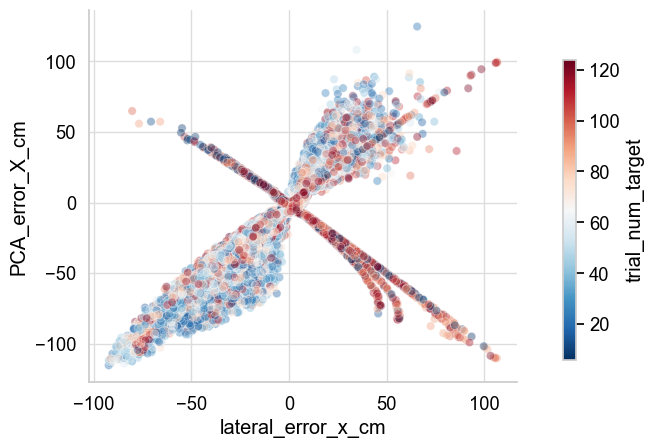

In [11]:
from src.plotting import plot_heatmap

plot_heatmap(PCA_error_df,
                     x_col = 'lateral_error_x_cm',
                     y_col='PCA_error_X_cm',
                     colour_col='trial_num_target',
                     mode='correlation', 
                     dark=False)

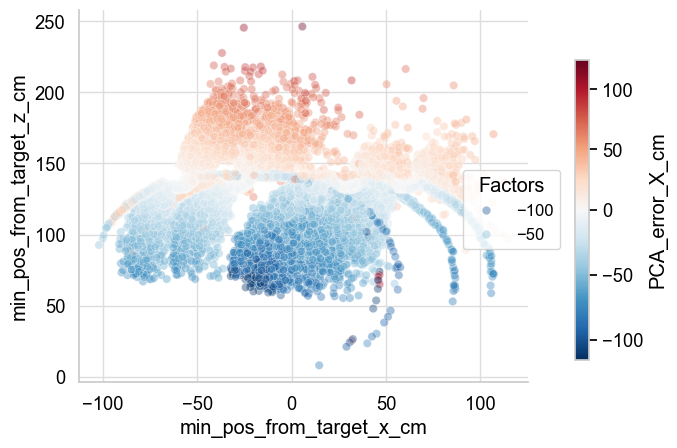

In [13]:
from src.plotting import plot_heatmap

plot_heatmap(PCA_error_df,
                     x_col = 'min_pos_from_target_x_cm',
                     y_col='min_pos_from_target_z_cm',
                     colour_col='PCA_error_X_cm',
                     mode='correlation', 
                     dark=False)

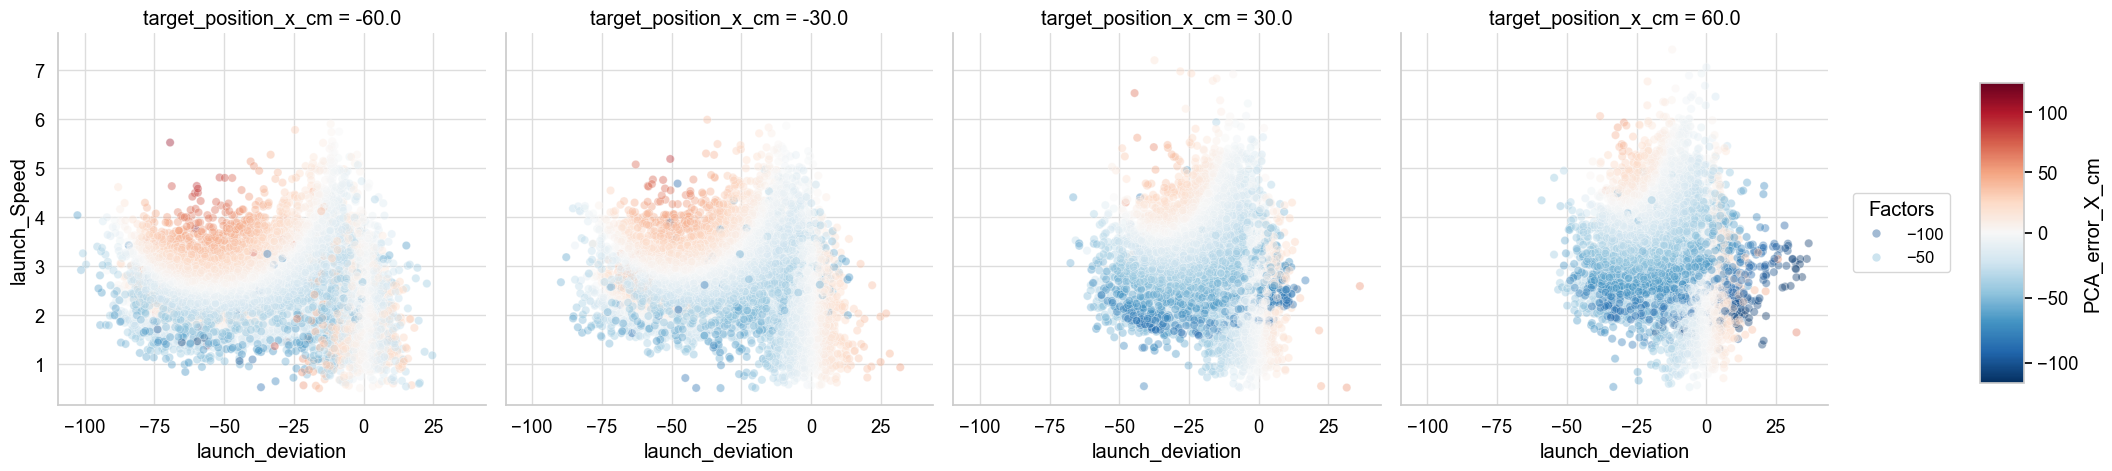

In [14]:
from src.plotting import plot_heatmap

plot_heatmap(PCA_error_df,
                     x_col = 'launch_deviation',
                     y_col='launch_Speed',
                     colour_col='PCA_error_X_cm',
                     facet_col='target_position_x_cm',
                     dark=False)

In [15]:
PCA_error_df['water_speed_binary']

0        0
1        0
2        0
3        0
4        0
        ..
39103    0
39104    0
39105    0
39106    0
39107    0
Name: water_speed_binary, Length: 39108, dtype: int8

In [19]:
PCA_error_df['phase']

0         baseline
1         baseline
2         baseline
3         baseline
4         baseline
           ...    
39103    washout_2
39104    washout_2
39105    washout_2
39106    washout_2
39107    washout_2
Name: phase, Length: 39108, dtype: category
Categories (5, object): ['baseline', 'training_1', 'training_2', 'washout_1', 'washout_2']

In [25]:
from src.early_late_exposure import early_late_phase

df_trial_sets = early_late_phase(df = PCA_error_df,
                 group_cols = ['ppid_full','set_order','target_x_label','speed_label'],
                 phase_col = 'phase',
                 trial_col = 'phase_target_trial_num',
                 n_trials = 4
                )
                 
from src.features import get_sample_sizes
get_sample_sizes(df_trial_sets, group_cols=['speed_label','experiment', 'set_order'], ppid_col='ppid_full')

C:\Users\jacob\water_current_MA\src\early_late_exposure.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_max = df.groupby(group_cols + [phase_col])[trial_col].transform('max')
C:\Users\jacob\water_current_MA\src\features.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_cols).size()


speed_label  experiment                       set_order
-3.0         S1-projectile_experiment         AB            0
                                              BA            0
             S1_3.0M-projectile_experiment 1  AB           20
                                              BA            0
             S2-projectile_experiment         AB            0
                                              BA            0
             S2_3.0M-projectile_experiment 1  AB            0
                                              BA           25
             projectile_experiment            AB            0
                                              BA            0
-2.0         S1-projectile_experiment         AB           15
                                              BA            0
             S1_3.0M-projectile_experiment 1  AB            0
                                              BA            0
             S2-projectile_experiment         AB            0
              

In [29]:
df_f = df_trial_sets[df_trial_sets['phase'] == 'baseline'].copy()
df_ft = df_f[df_f['trial_set'] == 'late'].copy()

participant_sd = df_ft.groupby('ppid_full')['PCA_error_X_cm'].std()

noise_threshold = participant_sd.quantile(0.75)

noisy_map = participant_sd > noise_threshold

df_ft['is_noisy'] = df_ft['ppid_full'].map(noisy_map)

df_ft['is_noisy'] = df_ft['is_noisy'].fillna(False)

df_ft_no_noise = df_ft[df_ft['is_noisy'] == False].copy()
pro_series = df_ft_no_noise['ppid_full']

# check participant counts per group:
from src.features import get_sample_sizes
get_sample_sizes(df_ft_no_noise, group_cols=['speed_label','experiment', 'set_order'], ppid_col='ppid_full')


C:\Users\jacob\AppData\Local\Temp\ipykernel_20564\2327741884.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  participant_sd = df_ft.groupby('ppid_full')['PCA_error_X_cm'].std()
C:\Users\jacob\water_current_MA\src\features.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_cols).size()


speed_label  experiment                       set_order
-3.0         S1-projectile_experiment         AB            0
                                              BA            0
             S1_3.0M-projectile_experiment 1  AB           15
                                              BA            0
             S2-projectile_experiment         AB            0
                                              BA            0
             S2_3.0M-projectile_experiment 1  AB            0
                                              BA           18
             projectile_experiment            AB            0
                                              BA            0
-2.0         S1-projectile_experiment         AB           14
                                              BA            0
             S1_3.0M-projectile_experiment 1  AB            0
                                              BA            0
             S2-projectile_experiment         AB            0
              

In [31]:
import pandas as pd

filtered_df = PCA_error_df[PCA_error_df['ppid_full'].isin(pro_series)]

dropped_df = PCA_error_df[~PCA_error_df['ppid_full'].isin(pro_series)]

In [37]:
print(filtered_df)
get_sample_sizes(filtered_df, group_cols=['speed_label','experiment', 'set_order'], ppid_col='ppid_full')

                            experiment  ppid_full speed_label target_x_label  \
1389            projectile_experiment   p005_neg2        -2.0            D60   
1390            projectile_experiment   p005_neg2        -2.0            D30   
1391            projectile_experiment   p005_neg2        -2.0            U60   
1392            projectile_experiment   p005_neg2        -2.0            U30   
1393            projectile_experiment   p005_neg2        -2.0            D60   
...                                ...        ...         ...            ...   
39103  S2_3.0M-projectile_experiment 1  p050_neg3        -3.0            U30   
39104  S2_3.0M-projectile_experiment 1  p050_neg3        -3.0            U30   
39105  S2_3.0M-projectile_experiment 1  p050_neg3        -3.0            D60   
39106  S2_3.0M-projectile_experiment 1  p050_neg3        -3.0            U30   
39107  S2_3.0M-projectile_experiment 1  p050_neg3        -3.0            D60   

       target_position_x_cm  target_pos

C:\Users\jacob\water_current_MA\src\features.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_cols).size()


speed_label  experiment                       set_order
-3.0         S1-projectile_experiment         AB            0
                                              BA            0
             S1_3.0M-projectile_experiment 1  AB           15
                                              BA            0
             S2-projectile_experiment         AB            0
                                              BA            0
             S2_3.0M-projectile_experiment 1  AB            0
                                              BA           18
             projectile_experiment            AB            0
                                              BA            0
-2.0         S1-projectile_experiment         AB           14
                                              BA            0
             S1_3.0M-projectile_experiment 1  AB            0
                                              BA            0
             S2-projectile_experiment         AB            0
              

In [ ]:
# SAVE PCA DF

In [ ]:

# Extract and join unique experiment strings
exp_tags = "_".join(df_labeled['experiment'].unique().astype(str))

# Extract unique water speeds, rounded to prevent floating point noise
speeds = df_labeled['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename
file_name = f"PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_path = f"..\\data\\{file_name}"

PCA_error_df.to_csv(file_path, index=False)
print(f"Saved: {file_path}")

In [ ]:
### PLOTS

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

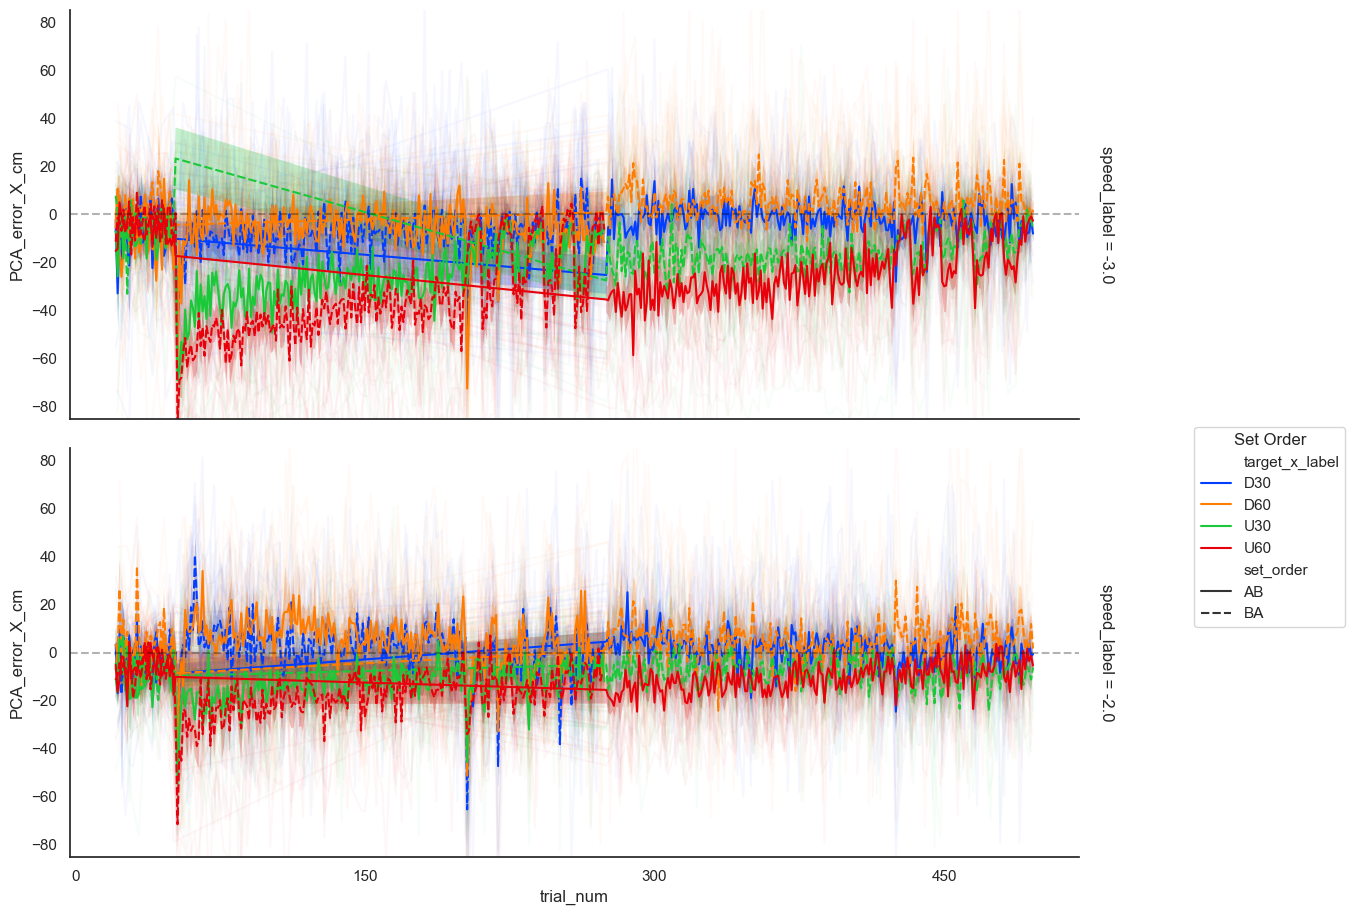

In [45]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(PCA_error_df, 
                     col_col = None,
                     row_col='speed_label',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_error_X_cm', 
                     x_col='trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-85,85),
                     show_zero_line=True
                    )

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

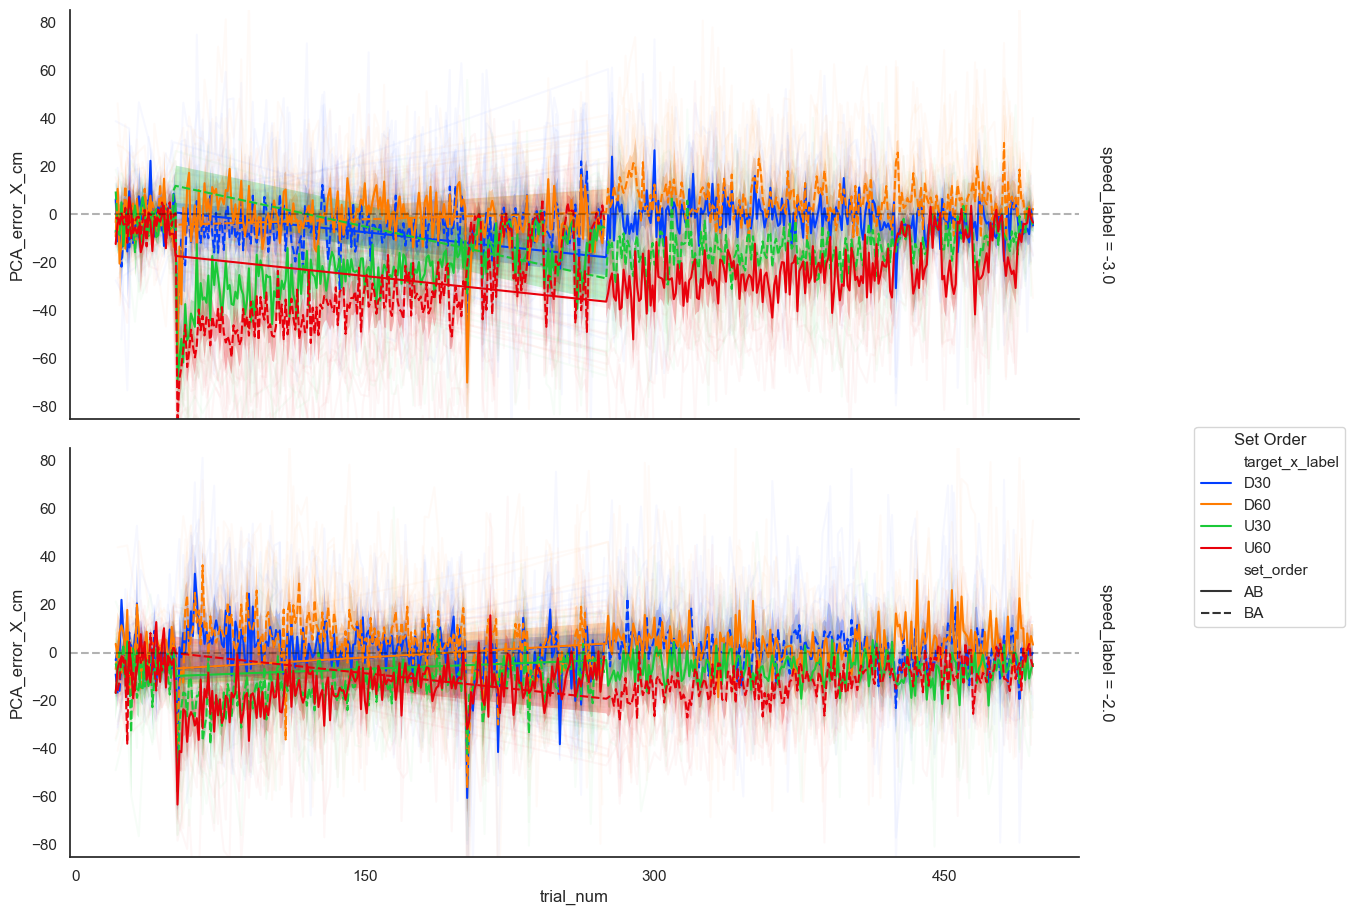

In [47]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(filtered_df, 
                     col_col = None,
                     row_col='speed_label',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_error_X_cm', 
                     x_col='trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-85,85),
                     show_zero_line=True
                    )

In [ ]:
# above is using: x = trial_num_target / y = PCA_error_X_cm

In [ ]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(PCA_error_df, 
                     col_col=None,
                     row_col='speed_label',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_deviation', 
                     x_col='trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-70,35),
                     show_zero_line=True
                    )

In [ ]:
# above is using: x = trial_num_target / y = launch_deviation

In [ ]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(PCA_error_df, 
                     col_col=None,
                     row_col='speed_label',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_Speed', 
                     x_col='trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(0.5,6.5),
                     show_zero_line=True
                    )

In [ ]:
# above is using: x = trial_num_target / y = launch_Speed

In [ ]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(PCA_error_df, 
                     row_col='speed_label',
                     col_col='phase',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_error_X_cm', 
                     x_col='phase_target_trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-85,85),
                     show_zero_line=True
                    )

In [ ]:
# above is using: x = phase_target_trial_num / y = PCA_error_X_cm

In [ ]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(PCA_error_df, 
                     row_col='speed_label',
                     col_col='phase',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_deviation', 
                     x_col='phase_target_trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-65,65),
                     show_zero_line=True
                    )

In [ ]:
# above is using: x = phase_target_trial_num / y = launch_deviation

In [ ]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(PCA_error_df, 
                     row_col='speed_label',
                     col_col='phase',
                     cond_col='set_order',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_Speed', 
                     x_col='phase_target_trial_num',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(0.5,6.5),
                     show_zero_line=True
                    )

In [ ]:
# above is using: x = phase_target_trial_num / y = launch_Speed

In [53]:
from src.early_late_exposure import early_late_phase

df_trial_sets = early_late_phase(df = filtered_df,
                 group_cols = ['ppid_full','set_order','target_x_label','speed_label'],
                 phase_col = 'phase',
                 trial_col = 'phase_target_trial_num',
                 n_trials = 4
                )
df_trial_sets

C:\Users\jacob\water_current_MA\src\early_late_exposure.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_max = df.groupby(group_cols + [phase_col])[trial_col].transform('max')


,experiment,ppid_full,speed_label,target_x_label,target_position_x_cm,target_position_z_cm,trial_num,phase,phase_target_trial_num,trial_num_target,...,centered_z,unrotated_x,unrotated_z,tgt_centered_x,tgt_centered_z,tgt_unrotated_x,tgt_unrotated_z,PCA_error_X_cm,PCA_error_Z_cm,trial_set
1389,projectile_experiment,p005_neg2,-2.0,D60,-60.0,140.0,21,baseline,1,6,...,0.731023,0.430309,0.694789,-5.964219,4.917723,-5.492578,5.439439,5.922887,-4.744650,early
1390,projectile_experiment,p005_neg2,-2.0,D30,-30.0,140.0,22,baseline,1,6,...,6.283696,-5.052651,-7.068377,-7.824067,4.931896,8.442332,-3.777122,-13.494983,-3.291255,early
1391,projectile_experiment,p005_neg2,-2.0,U60,60.0,140.0,23,baseline,1,6,...,0.715823,8.007383,3.380198,-3.743074,7.813523,6.938045,-5.188957,1.069339,8.569155,early
1392,projectile_experiment,p005_neg2,-2.0,U30,30.0,140.0,24,baseline,1,6,...,0.717805,0.199835,-0.691803,-5.212916,6.560305,7.193396,-4.297341,-6.993562,3.605539,early
1393,projectile_experiment,p005_neg2,-2.0,D60,-60.0,140.0,25,baseline,2,7,...,-1.697277,-1.288465,-1.586740,-5.964219,4.917723,-5.492578,5.439439,4.204113,-7.026178,early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39103,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,U30,30.0,140.0,492,washout_2,34,122,...,8.402305,20.037318,-1.419301,-5.212916,6.560305,7.193396,-4.297341,12.843922,2.878040,late
39104,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,U30,30.0,140.0,493,washout_2,35,123,...,1.354205,1.902303,-0.729558,-5.212916,6.560305,7.193396,-4.297341,-5.291093,3.567783,late
39105,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,D60,-60.0,140.0,494,washout_2,35,123,...,1.611923,1.744044,1.459453,-5.964219,4.917723,-5.492578,5.439439,7.236622,-3.979986,late
39106,S2_3.0M-projectile_experiment 1,p050_neg3,-3.0,U30,30.0,140.0,495,washout_2,36,124,...,6.017105,14.255134,-1.051908,-5.212916,6.560305,7.193396,-4.297341,7.061737,3.245434,late


C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarni

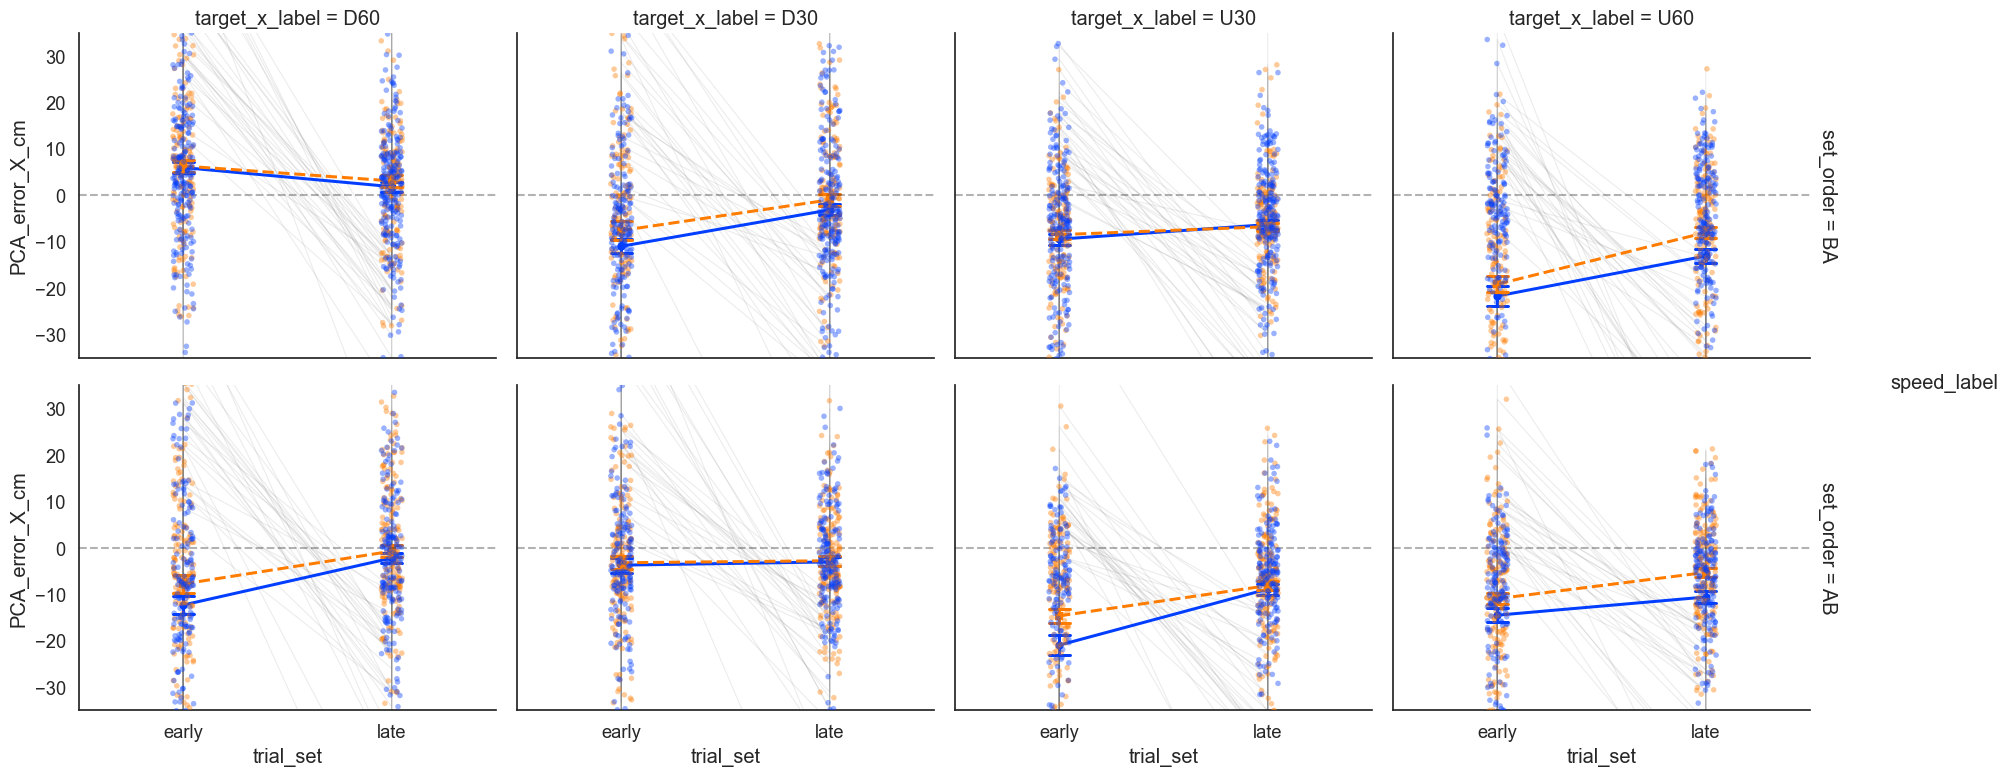

In [67]:
from src.plotting import plot_early_late_exposure

plot_early_late_exposure(df_trial_sets,
                         x_col='trial_set',
                         y_col='PCA_error_X_cm',
                         ylim=(-35,35),
                         line_col='set_order',
                         cond_col='speed_label', 
                         ppid_col='ppid_full',
                         facet_row='set_order',
                         facet_col='target_x_label',
                         show_zero_line=True)
#plot_early_late_exposure(early_late_10_means_dev)
#plot_early_late_exposure(early_late_10_means_speed)